# OU Alpaca paper-trading execution

This notebook pulls MA/V daily bars from Alpaca, applies the same OU strategy used in `ou_validation.ipynb`, and submits paper-trading market orders to align the account with the latest strategy position. It does not read `V_daily.csv` or `MA_daily.csv`.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from zoneinfo import ZoneInfo
from IPython.display import display

from alpaca.data.enums import Adjustment, DataFeed
from alpaca.data.historical.stock import StockHistoricalDataClient
from alpaca.data.requests import StockBarsRequest
from alpaca.data.timeframe import TimeFrame, TimeFrameUnit
from alpaca.trading.client import TradingClient
from alpaca.trading.enums import OrderSide, OrderType, TimeInForce
from alpaca.trading.requests import MarketOrderRequest

from alpaca_keys import AlpacaKeys


In [6]:
# Strategy symbols: spread = log(MA) - beta * log(V)
MA_SYMBOL = "MA"
V_SYMBOL = "V"
SYMBOLS = [V_SYMBOL, MA_SYMBOL]

PAPER = True
SUBMIT_ORDERS = True

DATA_START = "2008-03-19"
TEST_START = "2020-01-01"

# OU strategy parameters from ou_validation.ipynb.
HEDGE_LOOKBACK = 252
OU_LOOKBACK = 378
ENTRY_Z = 1.0
EXIT_Z = 0.75
E_STOP = 3.9
MIN_HALF_LIFE = 1
MAX_HALF_LIFE = 60
MIN_HOLD_DAYS = 1
COOLDOWN_DAYS = 1

# Regime filter settings. Thresholds are calibrated on pre-2020 data only.
REGIME_LOOKBACK = 126
BETA_STABILITY_LOOKBACK = 20
MIN_CORR_QUANTILE = 0.75
MAX_BETA_CHANGE_QUANTILE = 0.90
MAX_OU_SIGMA_QUANTILE = 0.90

USE_CORRELATION_FILTER = True
USE_BETA_STABILITY_FILTER = True
USE_OU_SIGMA_FILTER = True

# Execution sizing. Position +1 means long MA / short beta * V; -1 is the inverse.
MAX_GROSS_EXPOSURE = 100000.0
ROUND_TO_WHOLE_SHARES = True
MIN_TRADE_NOTIONAL = 10.0


In [7]:
keys = AlpacaKeys()
api_key = keys.api_key
secret_key = keys.secret_key

if not api_key or not secret_key:
    raise ValueError("Missing Alpaca API keys.")

trade_client = TradingClient(api_key=api_key, secret_key=secret_key, paper=PAPER)
data_client = StockHistoricalDataClient(api_key=api_key, secret_key=secret_key)

account = trade_client.get_account()
print("Account status:", account.status)
print("Buying power:", account.buying_power)
print("Paper trading:", PAPER)


Account status: AccountStatus.ACTIVE
Buying power: 200000
Paper trading: True


In [8]:
def load_alpaca_daily_prices(symbols, start_date):
    start = datetime.fromisoformat(start_date).replace(tzinfo=ZoneInfo("America/New_York"))
    end = datetime.now(ZoneInfo("America/New_York"))

    request = StockBarsRequest(
        symbol_or_symbols=symbols,
        timeframe=TimeFrame(amount=1, unit=TimeFrameUnit.Day),
        start=start,
        end=end,
        adjustment=Adjustment.RAW,
        feed=DataFeed.IEX,
    )
    bars = data_client.get_stock_bars(request).df

    if bars.empty:
        raise ValueError("Alpaca returned no daily bars for the configured symbols.")

    prices = bars["close"].unstack(level=0).dropna().copy()
    missing = sorted(set(symbols) - set(prices.columns))
    if missing:
        raise ValueError(f"Missing Alpaca price history for: {missing}")

    prices = prices[symbols].copy()
    prices.index = pd.to_datetime(prices.index)
    if prices.index.tz is not None:
        prices.index = prices.index.tz_convert(None)

    df = prices.reset_index().rename(columns={"timestamp": "Date", V_SYMBOL: "V", MA_SYMBOL: "MA"})
    if "Date" not in df.columns:
        df = df.rename(columns={df.columns[0]: "Date"})

    df["Date"] = pd.to_datetime(df["Date"]).dt.normalize()
    df = df.sort_values("Date").drop_duplicates("Date", keep="last").reset_index(drop=True)

    df["V_ret"] = df["V"].pct_change()
    df["MA_ret"] = df["MA"].pct_change()
    df["log_V"] = np.log(df["V"])
    df["log_MA"] = np.log(df["MA"])
    return df


df = load_alpaca_daily_prices(SYMBOLS, DATA_START)
display(df.tail())


symbol,Date,V,MA,V_ret,MA_ret,log_V,log_MA
1447,2026-05-05,322.090,497.050,-0.014744,-0.015431,5.774831,6.208691
1448,2026-05-06,318.730,491.600,-0.010432,-0.010965,5.764344,6.197665
1449,2026-05-07,321.345,501.150,0.008204,0.019426,5.772515,6.216905
1450,2026-05-08,318.690,495.440,-0.008262,-0.011394,5.764219,6.205446
1451,2026-05-11,323.905,497.855,0.016364,0.004874,5.780450,6.210309


In [9]:
def estimate_ou_params(spread_series):
    """Estimate discrete OU/AR(1) parameters from a trailing spread window."""
    x = np.asarray(spread_series, dtype=float)
    x = x[np.isfinite(x)]

    if len(x) < 20 or np.std(x[:-1]) == 0:
        return np.nan, np.nan, np.nan, np.nan, np.nan

    x_lag = x[:-1]
    x_next = x[1:]
    phi, intercept = np.polyfit(x_lag, x_next, 1)

    if not np.isfinite(phi) or phi <= 0 or phi >= 1:
        return np.nan, np.nan, np.nan, np.nan, np.nan

    theta = -np.log(phi)
    mu = intercept / (1 - phi)
    residuals = x_next - (intercept + phi * x_lag)
    residual_sigma = np.std(residuals, ddof=1)
    stationary_sigma = residual_sigma / np.sqrt(1 - phi**2)
    half_life = np.log(2) / theta if theta > 0 else np.nan

    return mu, phi, theta, stationary_sigma, half_life


def add_ou_features(price_df, hedge_lookback, ou_lookback, regime_lookback, beta_stability_lookback):
    features = price_df.copy().reset_index(drop=True)

    for col in ["beta", "spread", "ou_mu", "ou_phi", "ou_theta", "ou_sigma", "half_life", "ou_z"]:
        features[col] = np.nan

    log_v = features["log_V"].to_numpy()
    log_ma = features["log_MA"].to_numpy()
    start = max(hedge_lookback, ou_lookback + 2)

    for i in range(start, len(features)):
        hedge_start = i - hedge_lookback
        beta = np.polyfit(log_v[hedge_start:i], log_ma[hedge_start:i], 1)[0]
        features.loc[i, "beta"] = beta

        ou_start = i - ou_lookback
        spread_history = log_ma[ou_start:i] - beta * log_v[ou_start:i]
        ou_mu, ou_phi, ou_theta, ou_sigma, half_life = estimate_ou_params(spread_history)
        current_spread = log_ma[i] - beta * log_v[i]

        features.loc[i, "spread"] = current_spread
        features.loc[i, "ou_mu"] = ou_mu
        features.loc[i, "ou_phi"] = ou_phi
        features.loc[i, "ou_theta"] = ou_theta
        features.loc[i, "ou_sigma"] = ou_sigma
        features.loc[i, "half_life"] = half_life

        if np.isfinite(ou_sigma) and ou_sigma > 0:
            features.loc[i, "ou_z"] = (current_spread - ou_mu) / ou_sigma

    features["return_corr"] = features["V_ret"].rolling(regime_lookback).corr(features["MA_ret"])
    features["beta_change"] = features["beta"].diff().abs()
    features["beta_change_avg"] = features["beta_change"].rolling(beta_stability_lookback).mean()

    return features


In [10]:
def calibrate_regime_thresholds(feature_df):
    training_features = feature_df[(feature_df["Date"] >= "2000-01-01") & (feature_df["Date"] < TEST_START)].copy()

    return {
        "min_corr": training_features["return_corr"].quantile(MIN_CORR_QUANTILE),
        "max_beta_change": training_features["beta_change_avg"].quantile(MAX_BETA_CHANGE_QUANTILE),
        "max_ou_sigma": training_features["ou_sigma"].quantile(MAX_OU_SIGMA_QUANTILE),
    }


def run_ou_strategy(feature_df, evaluate_from, evaluate_to, regime_thresholds):
    result = feature_df.copy().reset_index(drop=True)

    result["corr_ok"] = True
    result["beta_stable"] = True
    result["ou_sigma_ok"] = True

    if USE_CORRELATION_FILTER:
        result["corr_ok"] = result["return_corr"] >= regime_thresholds["min_corr"]
    if USE_BETA_STABILITY_FILTER:
        result["beta_stable"] = result["beta_change_avg"] <= regime_thresholds["max_beta_change"]
    if USE_OU_SIGMA_FILTER:
        result["ou_sigma_ok"] = result["ou_sigma"] <= regime_thresholds["max_ou_sigma"]

    result["half_life_ok"] = result["half_life"].between(MIN_HALF_LIFE, MAX_HALF_LIFE)
    result["regime_ok"] = result[["corr_ok", "beta_stable", "ou_sigma_ok", "half_life_ok"]].all(axis=1)
    result["position"] = 0.0

    start_idx = int(result.index[result["Date"] >= evaluate_from][0])
    if evaluate_to is None:
        end_idx = len(result)
    else:
        end_candidates = result.index[result["Date"] >= evaluate_to]
        end_idx = int(end_candidates[0]) if len(end_candidates) else len(result)

    current_pos = 0
    entry_idx = None
    cooldown_remaining = 0

    for i in range(start_idx, end_idx):
        z = result.loc[i, "ou_z"]
        regime_ok = bool(result.loc[i, "regime_ok"])

        if pd.isna(z):
            result.loc[i, "position"] = current_pos
            continue

        if current_pos == 0:
            if cooldown_remaining > 0:
                cooldown_remaining -= 1
            elif regime_ok:
                if z > ENTRY_Z:
                    current_pos = -1
                    entry_idx = i
                elif z < -ENTRY_Z:
                    current_pos = 1
                    entry_idx = i

        elif current_pos == 1:
            holding_days = i - entry_idx if entry_idx is not None else 0
            if z < -E_STOP or not regime_ok or (holding_days >= MIN_HOLD_DAYS and z > -EXIT_Z):
                current_pos = 0
                entry_idx = None
                cooldown_remaining = COOLDOWN_DAYS

        elif current_pos == -1:
            holding_days = i - entry_idx if entry_idx is not None else 0
            if z > E_STOP or not regime_ok or (holding_days >= MIN_HOLD_DAYS and z < EXIT_Z):
                current_pos = 0
                entry_idx = None
                cooldown_remaining = COOLDOWN_DAYS

        result.loc[i, "position"] = current_pos

    result["beta_ffill"] = result["beta"].ffill()
    result["spread_ret"] = result["MA_ret"] - result["beta_ffill"] * result["V_ret"]
    result["position_lag"] = result["position"].shift(1).fillna(0)
    result["strategy_ret"] = (result["position_lag"] * result["spread_ret"]).fillna(0)

    result = result.iloc[start_idx:end_idx].copy().reset_index(drop=True)
    result["equity_curve"] = (1 + result["strategy_ret"]).cumprod()
    result["drawdown"] = result["equity_curve"] / result["equity_curve"].cummax() - 1
    return result


In [11]:
feature_df = add_ou_features(
    df,
    hedge_lookback=HEDGE_LOOKBACK,
    ou_lookback=OU_LOOKBACK,
    regime_lookback=REGIME_LOOKBACK,
    beta_stability_lookback=BETA_STABILITY_LOOKBACK,
)
regime_thresholds = calibrate_regime_thresholds(feature_df)
validation_df = run_ou_strategy(feature_df, evaluate_from=TEST_START, evaluate_to=None, regime_thresholds=regime_thresholds)

latest_signal = validation_df.dropna(subset=["ou_z", "beta"]).iloc[-1].copy()

metrics = {
    "start_date": validation_df["Date"].min(),
    "end_date": validation_df["Date"].max(),
    "latest_signal_date": latest_signal["Date"],
    "latest_position": latest_signal["position"],
    "latest_ou_z": latest_signal["ou_z"],
    "latest_beta": latest_signal["beta"],
    "latest_regime_ok": latest_signal["regime_ok"],
    "num_position_changes": int((validation_df["position"].diff().abs() > 0).sum()),
    "final_equity": validation_df["equity_curve"].iloc[-1],
}

display(pd.DataFrame([regime_thresholds]))
display(pd.DataFrame([metrics]))


,min_corr,max_beta_change,max_ou_sigma
0,NaN,NaN,NaN


,start_date,end_date,latest_signal_date,latest_position,latest_ou_z,latest_beta,latest_regime_ok,num_position_changes,final_equity
0,2020-07-27,2026-05-11,2026-05-11,0.0,-2.165524,0.920846,False,0,1.0


In [12]:
def target_notional_from_position(position, beta, gross_exposure):
    if position == 0 or not np.isfinite(beta):
        return {MA_SYMBOL: 0.0, V_SYMBOL: 0.0}

    ma_notional = position * gross_exposure / (1 + abs(beta))
    v_notional = -position * beta * gross_exposure / (1 + abs(beta))
    return {MA_SYMBOL: ma_notional, V_SYMBOL: v_notional}


def notional_to_qty(notional, price):
    raw_qty = notional / price
    if not ROUND_TO_WHOLE_SHARES:
        return round(raw_qty, 6)
    return float(np.sign(raw_qty) * np.floor(abs(raw_qty)))


def get_current_qty(symbol):
    try:
        position = trade_client.get_open_position(symbol)
        return float(position.qty)
    except Exception:
        return 0.0


latest_prices = {MA_SYMBOL: float(latest_signal["MA"]), V_SYMBOL: float(latest_signal["V"])}
target_notional = target_notional_from_position(
    position=float(latest_signal["position"]),
    beta=float(latest_signal["beta"]),
    gross_exposure=MAX_GROSS_EXPOSURE,
)

order_plan = []
for symbol in [MA_SYMBOL, V_SYMBOL]:
    current_qty = get_current_qty(symbol)
    target_qty = notional_to_qty(target_notional[symbol], latest_prices[symbol])
    trade_qty = target_qty - current_qty
    trade_notional = trade_qty * latest_prices[symbol]
    order_plan.append({
        "symbol": symbol,
        "latest_price": latest_prices[symbol],
        "current_qty": current_qty,
        "target_notional": target_notional[symbol],
        "target_qty": target_qty,
        "trade_qty": trade_qty,
        "trade_notional": trade_notional,
    })

order_plan_df = pd.DataFrame(order_plan)
display(order_plan_df)


,symbol,latest_price,current_qty,target_notional,target_qty,trade_qty,trade_notional
0,MA,497.855,0.0,0.0,0.0,0.0,0.0
1,V,323.905,0.0,0.0,0.0,0.0,0.0


In [13]:
def submit_market_order(symbol, trade_qty, latest_price):
    trade_notional = abs(trade_qty) * latest_price
    if abs(trade_qty) == 0 or trade_notional < MIN_TRADE_NOTIONAL:
        print(f"Skipping {symbol}: trade is below threshold.")
        return None

    side = OrderSide.BUY if trade_qty > 0 else OrderSide.SELL
    qty = abs(trade_qty)
    if ROUND_TO_WHOLE_SHARES:
        qty = int(qty)

    order = MarketOrderRequest(
        symbol=symbol,
        qty=qty,
        side=side,
        type=OrderType.MARKET,
        time_in_force=TimeInForce.DAY,
    )

    if not SUBMIT_ORDERS:
        print(f"[PREVIEW] {side.value} {qty} share(s) of {symbol}")
        return None

    result = trade_client.submit_order(order)
    print(f"Submitted paper {side.value} order for {qty} share(s) of {symbol}")
    return result


submitted_orders = []
for row in order_plan_df.itertuples(index=False):
    submitted_orders.append(submit_market_order(row.symbol, row.trade_qty, row.latest_price))

submitted_orders


Skipping MA: trade is below threshold.
Skipping V: trade is below threshold.


[None, None]

In [14]:
trade_log = validation_df[validation_df["position"].diff().fillna(0).abs() > 0].copy()
trade_log = trade_log[[
    "Date", "V", "MA", "beta", "spread", "ou_mu", "ou_sigma", "half_life", "ou_z",
    "return_corr", "beta_change_avg", "regime_ok", "position", "strategy_ret", "equity_curve", "drawdown"
]]

validation_yearly_returns = (
    validation_df
    .assign(year=validation_df["Date"].dt.year)
    .groupby("year")["strategy_ret"]
    .apply(lambda s: (1 + s).prod() - 1)
)

display(trade_log.tail(20))
display(validation_yearly_returns)


symbol,Date,V,MA,beta,spread,ou_mu,ou_sigma,half_life,ou_z,return_corr,beta_change_avg,regime_ok,position,strategy_ret,equity_curve,drawdown


year
2020    0.0
2021    0.0
2022    0.0
2023    0.0
2024    0.0
2025    0.0
2026    0.0
Name: strategy_ret, dtype: float64

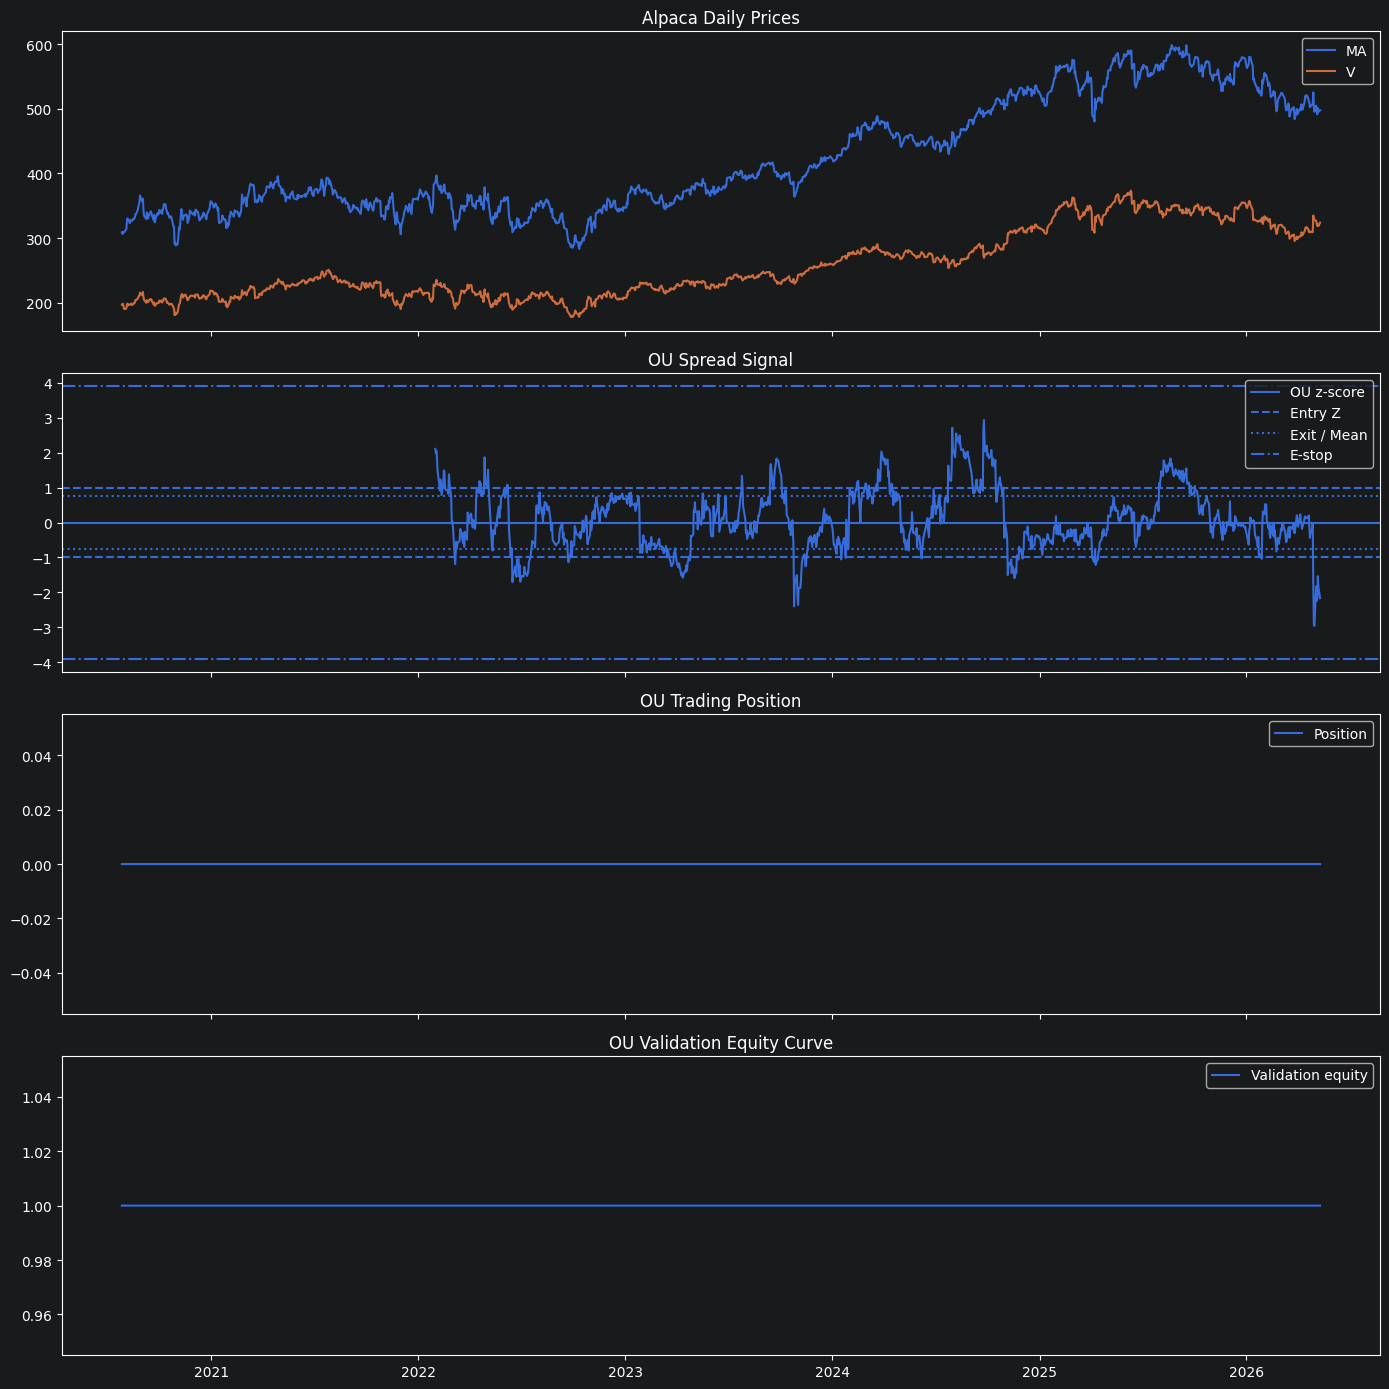

In [15]:
fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)

axes[0].plot(validation_df["Date"], validation_df["MA"], label="MA")
axes[0].plot(validation_df["Date"], validation_df["V"], label="V")
axes[0].set_title("Alpaca Daily Prices")
axes[0].legend()

axes[1].plot(validation_df["Date"], validation_df["ou_z"], label="OU z-score")
axes[1].axhline(ENTRY_Z, linestyle="--", label="Entry Z")
axes[1].axhline(-ENTRY_Z, linestyle="--")
axes[1].axhline(EXIT_Z, linestyle=":", label="Exit / Mean")
axes[1].axhline(-EXIT_Z, linestyle=":")
axes[1].axhline(E_STOP, linestyle="-.", label="E-stop")
axes[1].axhline(-E_STOP, linestyle="-.")
axes[1].axhline(0, linestyle="-")
axes[1].set_title("OU Spread Signal")
axes[1].legend()

axes[2].step(validation_df["Date"], validation_df["position"], where="post", label="Position")
axes[2].set_title("OU Trading Position")
axes[2].legend()

axes[3].plot(validation_df["Date"], validation_df["equity_curve"], label="Validation equity")
axes[3].set_title("OU Validation Equity Curve")
axes[3].legend()

plt.tight_layout()
plt.show()
